# Crawling & Analisis Data Polutan Udara di Kabupaten Pamekasan

<!-- # Pemantauan Kualitas Udara Kabupaten Pamekasan Berbasis Data Satelit Sentinel-5P -->

Nama : Rian Renaldy

NIM : 240411100053

Mata Kuliah : Pengantar Sains Data (PSD)

## Gambaran Wilayah Analisa

Kabupaten Pamekasan terletak di bagian tengah Pulau Madura, Provinsi Jawa Timur. Berbeda dari kawasan industri besar, karakter utama wilayah ini didominasi oleh **sektor agraris** (padi, jagung, tembakau), **peternakan sapi** (Pamekasan dikenal sebagai salah satu sentra karapan sapi di Madura), **produksi garam rakyat** di kawasan pesisir, serta aktivitas **perikanan tangkap** dengan kapal-kapal nelayan bermesin diesel. Selain itu, jalur distribusi barang lintas Madura (menghubungkan Bangkalan &ndash; Sampang &ndash; Pamekasan &ndash; Sumenep) turut menyumbang emisi kendaraan bermotor. Kombinasi aktivitas pertanian, peternakan, perikanan, dan transportasi darat ini berpotensi memengaruhi konsentrasi berbagai gas pencemar udara, meliputi Karbon Monoksida (CO), Nitrogen Dioksida (NO2), Sulfur Dioksida (SO2), Ozon troposferik (O3), Formaldehida (HCHO), dan Metana (CH4). Pemantauan keenam gas tersebut dari waktu ke waktu diperlukan untuk memahami karakteristik kualitas udara di Pamekasan.

## 1. Business Understanding

### 1.1 Tujuan Analisis

Menelusuri sumber-sumber utama polutan udara serta memetakan kondisi kualitas udara di wilayah Kabupaten Pamekasan, melalui pengambilan data satelit untuk enam parameter (CO, NO2, SO2, O3, HCHO, CH4), dilanjutkan dengan eksplorasi data (*data understanding*), dan divisualisasikan dalam bentuk *time series* untuk rentang waktu minimal satu tahun hingga 31 Agustus 2026.

### 1.2 Manfaat Analisis

1. Memetakan pola naik-turunnya konsentrasi tiap gas pencemar di Pamekasan sepanjang periode pengamatan.
2. Menduga kontribusi aktivitas lokal (pertanian, peternakan, produksi garam, perikanan, transportasi) terhadap tiap jenis polutan.
3. Menyediakan gambaran awal kualitas udara yang bisa menjadi rujukan warga maupun pemangku kebijakan setempat.
4. Menjadi pijakan data (baseline) untuk tahap pembersihan data dan pemodelan pada pertemuan berikutnya.
5. Melatih keterampilan pengambilan data satelit (remote sensing crawling) serta eksplorasi data deret waktu lingkungan.

### 1.3 Dugaan Sumber Tiap Polutan

| Polutan | Apa Itu? | Dugaan Sumber di Pamekasan |
|---|---|---|
| **CO** (Karbon Monoksida) | Gas tak berwarna & tak berbau, terbentuk dari pembakaran bahan bakar yang tidak sempurna | Knalpot kendaraan bermotor, mesin kapal nelayan diesel, pembakaran jerami/lahan pertanian sisa panen |
| **NO2** (Nitrogen Dioksida) | Gas oksida nitrogen hasil pembakaran suhu tinggi | Emisi kendaraan bermotor di jalur lintas Madura, genset/mesin diesel kapal nelayan dan penggilingan |
| **SO2** (Sulfur Dioksida) | Gas hasil pembakaran bahan bakar yang mengandung unsur belerang | Mesin kapal nelayan berbahan bakar solar, proses evaporasi/pengolahan air laut pada tambak garam, pembakaran bahan bakar fosil skala kecil |
| **O3** (Ozon Troposferik) | Bukan diemisikan langsung; polutan sekunder hasil reaksi fotokimia NOx dengan senyawa organik volatil di bawah sinar matahari | Terbentuk secara tidak langsung dari interaksi emisi kendaraan dan sinar matahari, umum meningkat pada siang hari cerah |
| **HCHO** (Formaldehida) | Senyawa organik volatil (VOC) hasil oksidasi hidrokarbon di atmosfer | Pembakaran biomassa/limbah pertanian, oksidasi metana dari peternakan, serta emisi kendaraan bermotor |
| **CH4** (Metana) | Gas rumah kaca, terkait erat dengan siklus biologis | Fermentasi enterik ternak sapi, lahan sawah tergenang air, dan dekomposisi limbah organik/TPA |

### 1.4 Deskripsi Umum Data

Data yang dipakai bersumber dari misi satelit **Sentinel-5P (instrumen TROPOMI)** yang dikelola oleh Copernicus/ESA, diakses melalui layanan **openEO** pada **Copernicus Data Space Ecosystem (CDSE)**. Data berupa nilai kerapatan kolom (*column density*) harian tiap gas pada resolusi grid tertentu, yang kemudian dirata-ratakan dalam batas wilayah analisa untuk membentuk satu nilai per hari per polutan.

## 2. Penetapan Area Analisa (AOI) Melalui GeoJSON.io

Batas wilayah pengambilan data digambar secara manual pada [geojson.io](https://geojson.io) dalam bentuk poligon yang mencakup Kabupaten Pamekasan, lalu diekspor sebagai berkas `.geojson`. Dari poligon tersebut dihitung *bounding box* (kotak pembatas terluar) yang menjadi parameter `spatial_extent` saat memanggil data pada openEO.

In [1]:
import json

# Poligon area analisa (AOI) Kabupaten Pamekasan, hasil gambar manual pada geojson.io
aoi_pamekasan = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [113.5876958, -6.9670461],
                        [113.603825, -7.0270799],
                        [113.6179379, -7.1151155],
                        [113.5554375, -7.1931807],
                        [113.5272115, -7.2511372],
                        [113.4827865, -7.2244607],
                        [113.4264044, -7.2191357],
                        [113.4042268, -7.0911074],
                        [113.4324528, -6.9830559],
                        [113.4243882, -6.8889907],
                        [113.5872728371105, -6.898785199566333],
                        [113.5876958, -6.9670461]
                    ]
                ]
            }
        }
    ]
}

with open("aoi_pamekasan.geojson", "w") as f:
    json.dump(aoi_pamekasan, f, indent=2)

print("Berkas aoi_pamekasan.geojson tersimpan.")


Berkas aoi_pamekasan.geojson tersimpan.


In [2]:
with open("aoi_pamekasan.geojson", "r") as f:
    aoi_pamekasan = json.load(f)

titik_poligon = aoi_pamekasan["features"][0]["geometry"]["coordinates"][0]
daftar_lon = [titik[0] for titik in titik_poligon]
daftar_lat = [titik[1] for titik in titik_poligon]

kotak_wilayah = {
    "west": min(daftar_lon),
    "south": min(daftar_lat),
    "east": max(daftar_lon),
    "north": max(daftar_lat),
}

print("Bounding box wilayah Analisa (Pamekasan):")
print(kotak_wilayah)


Bounding box wilayah Analisa (Pamekasan):
{'west': 113.4042268, 'south': -7.2511372, 'east': 113.6179379, 'north': -6.8889907}


![image](https://hackmd.io/_uploads/Bk9v1xAwMl.png)

## 3. Pengambilan Data (Crawling) via openEO &mdash; Copernicus Data Space Ecosystem

### 3.1 Instalasi & Autentikasi

In [3]:
!pip install openeo


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.2/349.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [4]:
import openeo

koneksi = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()


Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=QDFH-JUZC 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


### 3.2 Mengunduh Enam Parameter Polutan

Rentang waktu ditetapkan **1 tahun penuh**, dari **31 Agustus 2025** sampai **31 Agustus 2026**, memenuhi ketentuan tugas (data terkini, minimal satu tahun sampai 31 Agustus 2026). Karena koleksi `SENTINEL_5P_L2` pada openEO hanya mengizinkan satu *band* per permintaan, pengambilan data dilakukan bergiliran untuk tiap polutan menggunakan perulangan, dan masing-masing hasil disimpan sebagai berkas NetCDF (`.nc`) terpisah.

> **Catatan:** jika notebook dijalankan sebelum tanggal 31 Agustus 2026, cakupan data hanya akan sampai pada tanggal perekaman satelit terakhir yang tersedia saat itu. Jalankan ulang mendekati/ setelah tanggal tersebut untuk mendapatkan rentang data yang benar-benar penuh satu tahun.

In [5]:
daftar_polutan = ["CO", "NO2", "SO2", "O3", "HCHO", "CH4"]

tanggal_mulai = "2025-08-31"
tanggal_akhir = "2026-08-31"

for gas in daftar_polutan:
    kubus_data = koneksi.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=[tanggal_mulai, tanggal_akhir],
        spatial_extent=kotak_wilayah,
        bands=[gas],
    )
    kubus_harian = kubus_data.aggregate_temporal_period(reducer="mean", period="day")
    kubus_harian.execute_batch(title=f"{gas} Pamekasan", outputfile=f"{gas}_pamekasan.nc")
    print(f"Data {gas} selesai diunduh -> {gas}_pamekasan.nc")


0:00:00 Job 'j-26083014471149e6890909b854393195': send 'start'
0:00:03 Job 'j-26083014471149e6890909b854393195': created (progress 0%)
0:00:08 Job 'j-26083014471149e6890909b854393195': queued (progress 0%)
0:00:14 Job 'j-26083014471149e6890909b854393195': queued (progress 0%)
0:00:22 Job 'j-26083014471149e6890909b854393195': queued (progress 0%)
0:00:32 Job 'j-26083014471149e6890909b854393195': queued (progress 0%)
0:00:45 Job 'j-26083014471149e6890909b854393195': queued (progress 0%)
0:01:00 Job 'j-26083014471149e6890909b854393195': running (progress N/A)
0:01:19 Job 'j-26083014471149e6890909b854393195': running (progress N/A)
0:01:43 Job 'j-26083014471149e6890909b854393195': running (progress N/A)
0:02:13 Job 'j-26083014471149e6890909b854393195': running (progress N/A)
0:02:50 Job 'j-26083014471149e6890909b854393195': running (progress N/A)
0:03:37 Job 'j-26083014471149e6890909b854393195': running (progress N/A)
0:04:35 Job 'j-26083014471149e6890909b854393195': finished (progress 100

Status N/A yang muncul pada proses running dapat diabaikan karena hanya menunjukkan bahwa persentase progres tidak dapat ditampilkan oleh server pada saat itu. Selama status job masih berada pada kondisi running, proses pengolahan data tetap berjalan normal.
Selain melalui terminal, proses pengambilan data juga dapat dipantau melalui halaman OpenEO Editor:

[openEO Web Editor](https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2)

Pada halaman tersebut akan ditampilkan daftar job yang pernah dijalankan, termasuk nama dataset, status proses, waktu eksekusi, serta file hasil yang dapat diunduh setelah proses selesai. Dengan demikian, pengguna dapat memantau perkembangan pengambilan data secara langsung hingga status berubah menjadi finished.

![image](https://hackmd.io/_uploads/S1l9eg0Pzl.png)

## 4. Data Understanding

### 4.1 Membaca Berkas NetCDF & Menyimpan sebagai CSV

Tiap berkas `.nc` dibuka menggunakan `netCDF4`, dihitung rata-rata harian pada seluruh grid dalam wilayah analisa (mengabaikan piksel yang tertutup awan/*masked*), lalu digabungkan berdasarkan tanggal menjadi satu tabel dan disimpan ke satu berkas CSV.

In [6]:
!pip install netCDF4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.4 MB/s eta 0:00:00


In [7]:
import netCDF4
import numpy as np
import pandas as pd


def baca_rata_rata_harian(nama_band, nama_berkas):
    dataset = netCDF4.Dataset(nama_berkas)

    nilai = dataset.variables[nama_band][:]
    waktu = dataset.variables["t"][:]
    satuan_waktu = dataset.variables["t"].units

    tanggal = netCDF4.num2date(waktu, units=satuan_waktu)
    tanggal_harian = [t.strftime("%Y-%m-%d") for t in tanggal]

    rata_harian = []
    for idx in range(len(nilai)):
        grid_harian = nilai[idx]
        nilai_rata = np.ma.mean(grid_harian)

        if np.ma.is_masked(nilai_rata):
            nilai_rata = np.nan
        else:
            nilai_rata = float(nilai_rata)

        rata_harian.append(nilai_rata)

    df_hasil = pd.DataFrame({"tanggal": tanggal_harian, nama_band: rata_harian})
    df_hasil["tanggal"] = pd.to_datetime(df_hasil["tanggal"])
    df_hasil[nama_band] = pd.to_numeric(df_hasil[nama_band], errors="coerce")

    return df_hasil


kumpulan_df = {}
for gas in daftar_polutan:
    df_gas = baca_rata_rata_harian(gas, f"{gas}_pamekasan.nc")
    kumpulan_df[gas] = df_gas
    print(f"{gas}: {df_gas.shape[0]} baris berhasil dibaca")

# Gabungkan seluruh polutan berdasarkan kolom tanggal
df_polutan_pamekasan = kumpulan_df[daftar_polutan[0]][["tanggal"]].copy()
for gas in daftar_polutan:
    df_polutan_pamekasan = df_polutan_pamekasan.merge(
        kumpulan_df[gas][["tanggal", gas]], on="tanggal", how="outer"
    )

df_polutan_pamekasan = df_polutan_pamekasan.sort_values("tanggal").reset_index(drop=True)
df_polutan_pamekasan.to_csv("data_polutan_pamekasan.csv", index=False)

print(f"\nBerhasil menyimpan {len(df_polutan_pamekasan)} baris ke data_polutan_pamekasan.csv")


CO: 365 baris berhasil dibaca
NO2: 363 baris berhasil dibaca
SO2: 362 baris berhasil dibaca
O3: 362 baris berhasil dibaca
HCHO: 362 baris berhasil dibaca
CH4: 213 baris berhasil dibaca

Berhasil menyimpan 365 baris ke data_polutan_pamekasan.csv


![image](https://hackmd.io/_uploads/rJyhR6WOGg.png)

Kemudian di download untuk melihat hasil pengambilan data

![image](https://hackmd.io/_uploads/By1_ApbOMl.png)




### 4.2 Eksplorasi Struktur & Isi Data

In [8]:
print("=== Struktur Data Polutan Pamekasan ===")
df_polutan_pamekasan.info()

print("\n=== Ukuran Dataset ===")
print("Jumlah baris :", df_polutan_pamekasan.shape[0])
print("Jumlah kolom :", df_polutan_pamekasan.shape[1])

print("\n=== Nama Kolom ===")
print(df_polutan_pamekasan.columns.tolist())

print("\n=== Lima Data Teratas ===")
display(df_polutan_pamekasan.head())

print("\n=== Lima Data Terbawah ===")
display(df_polutan_pamekasan.tail())


=== Struktur Data Polutan Pamekasan ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   tanggal  365 non-null    datetime64[ns]
 1   CO       252 non-null    float64       
 2   NO2      279 non-null    float64       
 3   SO2      305 non-null    float64       
 4   O3       361 non-null    float64       
 5   HCHO     313 non-null    float64       
 6   CH4      92 non-null     float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 20.1 KB

=== Ukuran Dataset ===
Jumlah baris : 365
Jumlah kolom : 7

=== Nama Kolom ===
['tanggal', 'CO', 'NO2', 'SO2', 'O3', 'HCHO', 'CH4']

=== Lima Data Teratas ===


,tanggal,CO,NO2,SO2,O3,HCHO,CH4
0,2025-08-31,0.028413,0.000012,-0.000103,0.116304,0.000152,NaN
1,2025-09-01,0.026705,0.000006,-0.000069,0.115098,0.000043,NaN
2,2025-09-02,0.025357,0.000007,0.000013,0.114357,0.000046,NaN
3,2025-09-03,0.026524,0.000011,0.000019,0.113698,0.000067,1890.583083
4,2025-09-04,0.026057,0.000013,-0.000011,0.113273,0.000092,1840.894531



=== Lima Data Terbawah ===


,tanggal,CO,NO2,SO2,O3,HCHO,CH4
360,2026-08-26,0.027989,0.000020,0.000111,0.118790,0.000116,1907.810724
361,2026-08-27,0.029515,0.000025,0.000058,0.118135,0.000178,1901.543380
362,2026-08-28,0.032623,0.000021,0.000075,0.116215,0.000184,1896.543457
363,2026-08-29,NaN,0.000013,-0.000028,0.116368,0.000025,NaN
364,2026-08-30,0.030614,0.000014,0.000010,0.114166,0.000115,1884.014160


### 4.3 Penjelasan Tiap Fitur

- **tanggal** &mdash; tanggal observasi harian (hasil agregasi rata-rata dari seluruh piksel di wilayah analisa).
- **CO** &mdash; kerapatan kolom karbon monoksida (mol/m&sup2;); indikator pembakaran tidak sempurna.
- **NO2** &mdash; kerapatan kolom nitrogen dioksida (mol/m&sup2;); indikator emisi kendaraan/pembakaran suhu tinggi.
- **SO2** &mdash; kerapatan kolom sulfur dioksida (mol/m&sup2;); indikator pembakaran bahan bakar bersulfur.
- **O3** &mdash; kerapatan kolom ozon troposferik (mol/m&sup2;); polutan sekunder hasil fotokimia.
- **HCHO** &mdash; kerapatan kolom formaldehida (mol/m&sup2;); indikator VOC dan pembakaran biomassa.
- **CH4** &mdash; kerapatan kolom metana (mol/m&sup2; atau ppb tergantung produk); terkait aktivitas biologis/peternakan/pertanian.

### 4.4 Pengecekan Missing Value

Nilai kosong (`NaN`) pada data Sentinel-5P umumnya disebabkan oleh **tutupan awan** yang menghalangi sensor optik satelit pada tanggal tertentu, bukan kesalahan pencatatan data.

In [9]:
print(f"{'Polutan':<8}{'Total Baris':<14}{'Jumlah Kosong':<16}{'Persentase':<10}")

for gas in daftar_polutan:
    total_baris = len(df_polutan_pamekasan)
    jumlah_kosong = df_polutan_pamekasan[gas].isna().sum()
    persentase = jumlah_kosong / total_baris * 100 if total_baris > 0 else 0
    print(f"{gas:<8}{total_baris:<14}{jumlah_kosong:<16}{persentase:.2f}%")


Polutan Total Baris   Jumlah Kosong   Persentase
CO      365           113             30.96%
NO2     365           86              23.56%
SO2     365           60              16.44%
O3      365           4               1.10%
HCHO    365           52              14.25%
CH4     365           273             74.79%


### 4.5 Eksplorasi Data Seluas-luasnya & Pengecekan Data Aneh (Outlier)

Statistik deskriptif serta deteksi outlier dengan metode **IQR (Interquartile Range)** digunakan untuk melihat sebaran nilai tiap gas dan mengidentifikasi kejanggalan data.

In [10]:
ringkasan = []

for gas in daftar_polutan:
    nilai_valid = df_polutan_pamekasan[gas].dropna()

    kuartil_1 = nilai_valid.quantile(0.25)
    kuartil_3 = nilai_valid.quantile(0.75)
    rentang_iqr = kuartil_3 - kuartil_1

    batas_bawah = kuartil_1 - 1.5 * rentang_iqr
    batas_atas = kuartil_3 + 1.5 * rentang_iqr

    jumlah_outlier = ((nilai_valid < batas_bawah) | (nilai_valid > batas_atas)).sum()

    ringkasan.append({
        "Polutan": gas,
        "Min": nilai_valid.min(),
        "Max": nilai_valid.max(),
        "Rata-rata": nilai_valid.mean(),
        "Std": nilai_valid.std(),
        "Q1": kuartil_1,
        "Q3": kuartil_3,
        "IQR": rentang_iqr,
        "Batas Bawah": batas_bawah,
        "Batas Atas": batas_atas,
        "Jumlah Outlier": jumlah_outlier,
    })

df_ringkasan = pd.DataFrame(ringkasan)
display(df_ringkasan)


,Polutan,Min,Max,Rata-rata,Std,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier
0,CO,0.019084,0.036531,0.027883,0.002652,0.026000,0.029433,0.003433,2.084954e-02,0.034583,4
1,NO2,-0.000005,0.000037,0.000016,0.000006,0.000012,0.000020,0.000008,5.824531e-07,0.000032,8
2,SO2,-0.001046,0.000415,0.000029,0.000127,-0.000022,0.000081,0.000103,-1.770098e-04,0.000236,24
3,O3,0.110342,0.122254,0.115667,0.002227,0.114128,0.116939,0.002811,1.099111e-01,0.121155,5
4,HCHO,-0.000324,0.000454,0.000126,0.000076,0.000081,0.000158,0.000077,-3.374532e-05,0.000273,16
5,CH4,1715.889160,1921.731027,1880.284557,33.475818,1866.786540,1900.927646,34.141107,1.815575e+03,1952.139306,4


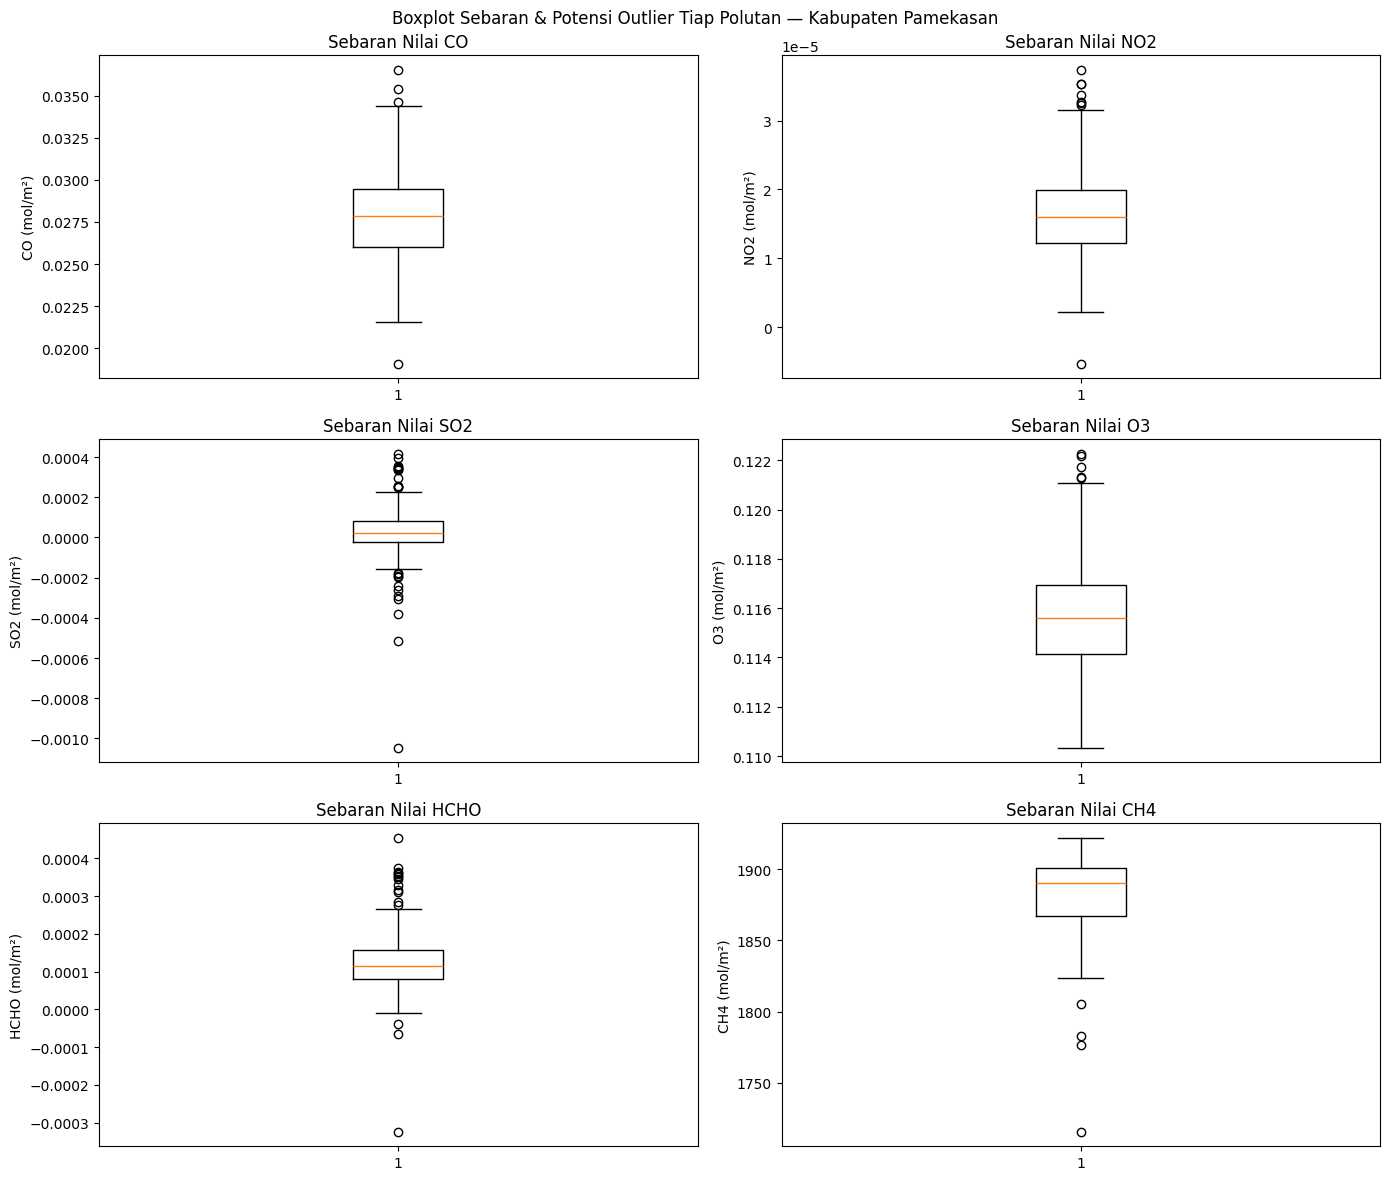

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for ax, gas in zip(axes.flatten(), daftar_polutan):
    ax.boxplot(df_polutan_pamekasan[gas].dropna())
    ax.set_title(f"Sebaran Nilai {gas}")
    ax.set_ylabel(f"{gas} (mol/m²)")

fig.suptitle("Boxplot Sebaran & Potensi Outlier Tiap Polutan — Kabupaten Pamekasan")
plt.tight_layout()
plt.show()


> Perlu dicatat bahwa nilai negatif pada data kolom Sentinel-5P adalah hal yang **wajar** akibat *noise* sensor, terutama pada wilayah dengan konsentrasi gas yang rendah &mdash; sehingga tidak semua outlier hasil IQR otomatis berarti kesalahan data. Beberapa titik outlier justru bisa mengindikasikan kejadian nyata, misalnya musim pembakaran lahan pertanian atau lonjakan aktivitas kapal nelayan.

## 5. Visualisasi Time Series

Grafik berikut menampilkan perubahan konsentrasi tiap gas polutan di Kabupaten Pamekasan sepanjang periode analisa, menggunakan data harian apa adanya (belum melalui tahap pembersihan/imputasi, karena tugas ini masih dibatasi hingga tahap *Data Understanding*).

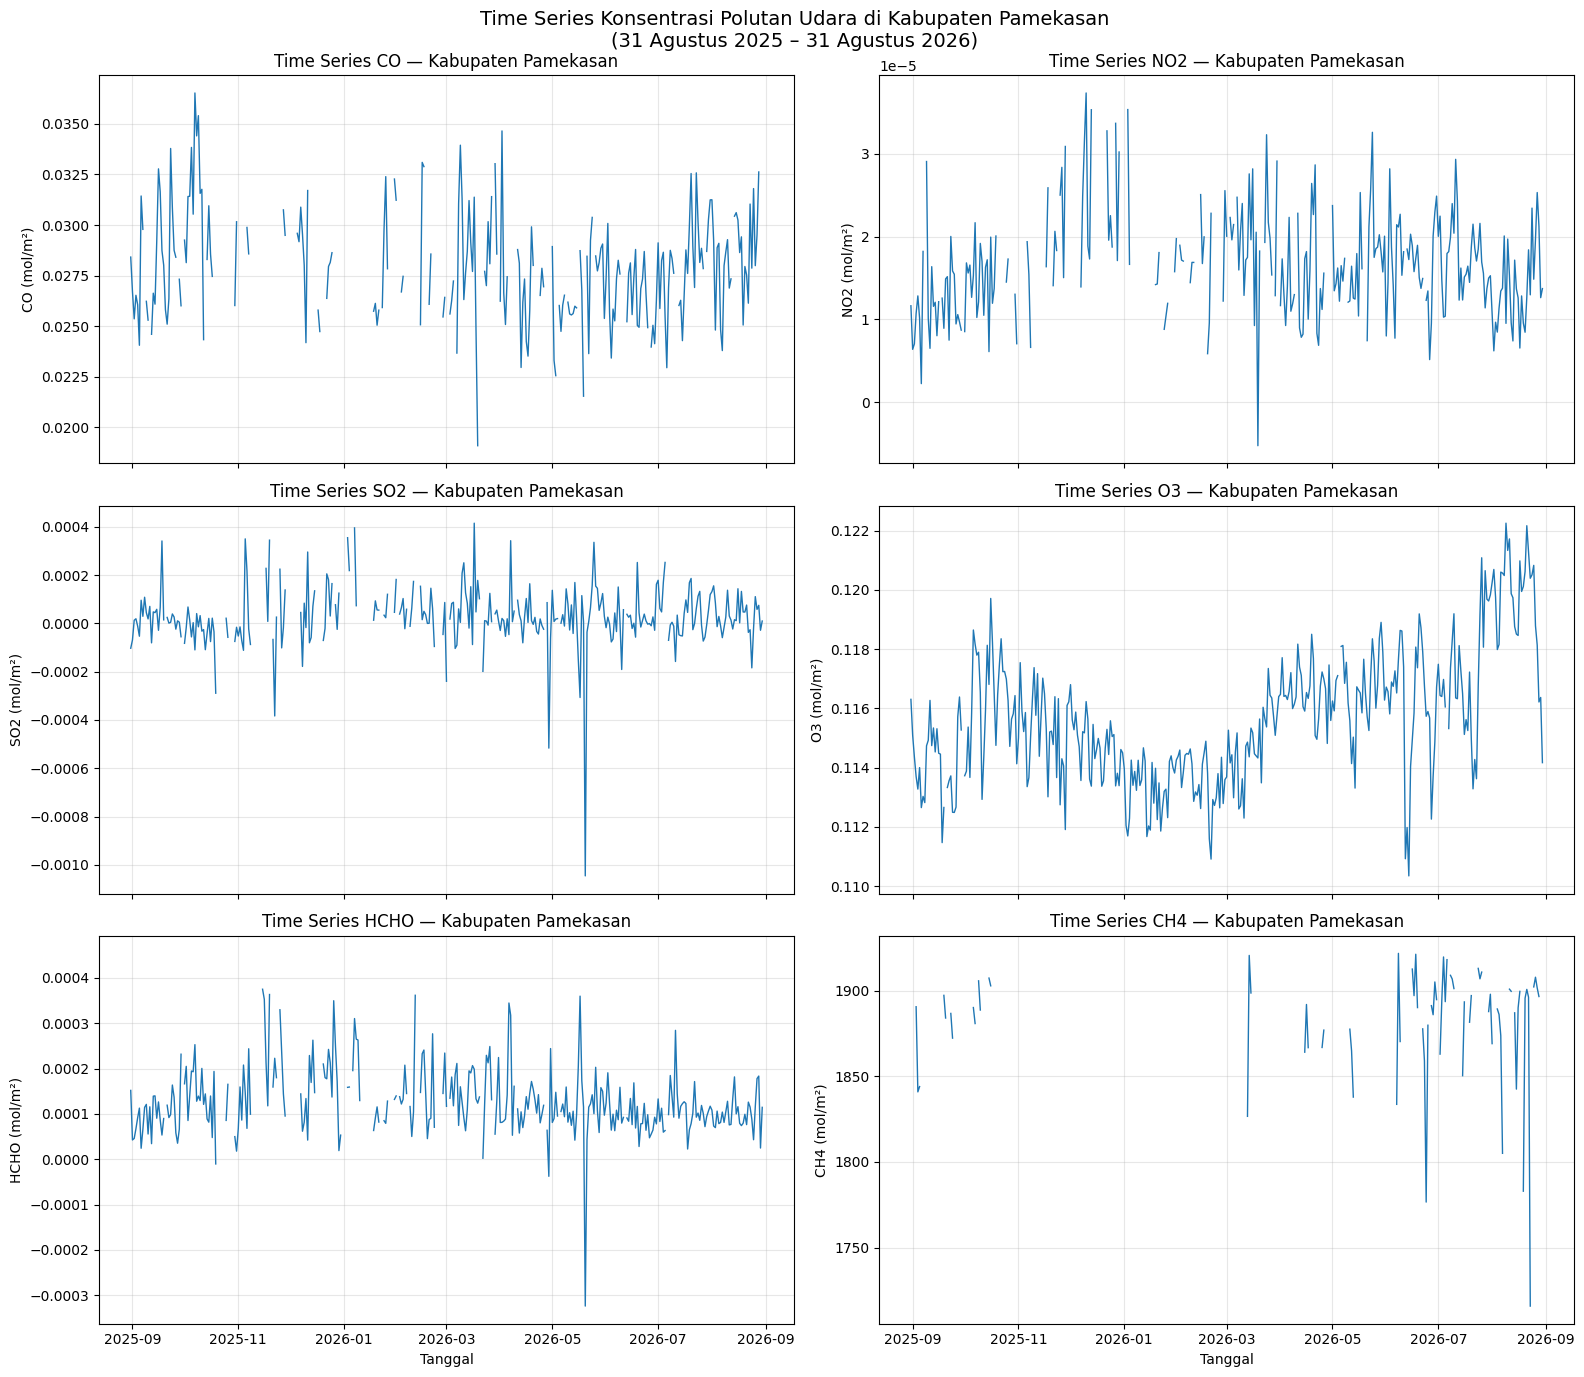

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)

for ax, gas in zip(axes.flatten(), daftar_polutan):
    ax.plot(df_polutan_pamekasan["tanggal"], df_polutan_pamekasan[gas], linewidth=1, color="tab:blue")
    ax.set_title(f"Time Series {gas} — Kabupaten Pamekasan")
    ax.set_ylabel(f"{gas} (mol/m²)")
    ax.grid(alpha=0.3)

axes[-1, 0].set_xlabel("Tanggal")
axes[-1, 1].set_xlabel("Tanggal")

fig.suptitle("Time Series Konsentrasi Polutan Udara di Kabupaten Pamekasan\n(31 Agustus 2025 – 31 Agustus 2026)", fontsize=14)
plt.tight_layout()
plt.show()


## Kesimpulan

Melalui tugas ini, data konsentrasi enam polutan udara (CO, NO2, SO2, O3, HCHO, dan CH4) di Kabupaten Pamekasan berhasil diperoleh dari satelit Sentinel-5P menggunakan layanan openEO pada Copernicus Data Space Ecosystem, dengan wilayah analisa dibatasi melalui berkas GeoJSON yang digambar di geojson.io. Karena keterbatasan satu *band* per permintaan pada API, pengambilan data dilakukan bergiliran untuk tiap gas dan hasil akhirnya digabungkan menjadi satu berkas CSV. Tahap *data understanding* yang dilakukan mencakup pemeriksaan struktur dan isi data, deskripsi tiap fitur, identifikasi missing value (umumnya akibat tutupan awan), serta deteksi data anomali/outlier dengan metode IQR. Grafik *time series* yang dihasilkan menunjukkan pola fluktuasi tiap polutan sepanjang satu tahun pengamatan, yang diduga berkaitan dengan aktivitas pertanian, peternakan sapi, produksi garam, perikanan, serta lalu lintas kendaraan di wilayah Pamekasan. Temuan tahap ini menjadi dasar bagi tahap pembersihan data dan pemodelan lanjutan pada pertemuan berikutnya.